In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [16]:
class model:
    def __init__(self,layers):
        self.layers = layers
        self.layer_length = len(self.layers)

        self.weights = []
        self.bias = []
        self._cache = []

        for i in range(self.layer_length - 1):
            w = np.random.randn(layers[i+1],layers[i]) * 1 / np.sqrt(layers[i])
            b = np.zeros((layers[i+1],1))

            self.weights.append(w)
            self.bias.append(b)

    def Relu(self,z):
        return np.maximum(0,z)
    
    def Relu_deriv(self,z):
        return (z>0).astype(float)
    
    def sigmoid(self,z):
        return 1/(1 + np.exp(-z))
    
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
        return exp_z / np.sum(exp_z, axis=0, keepdims=True)
    
    @staticmethod
    def one_hot_encode(Y, num_classes=10):
        one_hot_Y = np.zeros((num_classes, Y.size))
        one_hot_Y[Y.astype(int), np.arange(Y.size)] = 1

        return one_hot_Y.astype(float)
    
    def forward(self,x):
        a_prev = x
        self._cache = []

        for i in range(len(self.weights)):
            z = self.weights[i] @ a_prev + self.bias[i]
            
            if(i == len(self.weights) - 1):
                a_l = self.softmax(z)
            else:
                a_l = self.Relu(z)
                

            self._cache.append((z, a_prev))
            a_prev = a_l
    
        return a_prev

    def backprop(self,y,y_hat):
        M = y_hat.shape[1]
        L = len(self.weights)
        grads = {}

        dZ = y_hat - y

        for i in reversed(range(L)):
            z_curr, a_prev = self._cache[i]

            w_curr = self.weights[i]

            grads['dW' + str(i)] = (1 / M) * dZ @ a_prev.T
            grads['db' + str(i)] = (1 / M) * np.sum(dZ, axis=1, keepdims=True)

            if i != 0:
                dA = self.weights[i].T @ dZ
                z_prev, _ = self._cache[i-1]
                dZ = dA * self.Relu_deriv(z_prev)

        return grads   

    def update_params(self,grad,learning_rate):
        for i in range(len(self.weights)):
            self.weights[i] -= learning_rate * grad['dW' + str(i)] 
            self.bias[i] -= learning_rate * grad['db' + str(i)]



In [17]:
def train(model, x_train, y_train_oh, learning_rate, epoch, batch_size=256):
    M = x_train.shape[1]
    
    for epochs in range(epoch):
        indices = np.random.permutation(M)
        
        epoch_loss = 0
        num_batches = 0

        for i in range(0, M, batch_size):
            batch_idx = indices[i:i+batch_size]
            x_batch = x_train[:, batch_idx]
            y_batch = y_train_oh[:, batch_idx]
            
            y_hat = model.forward(x_batch)
            
            batch_m = x_batch.shape[1]
            loss = - (1 / batch_m) * np.sum(y_batch * np.log(y_hat + 1e-8))
            epoch_loss += loss
            num_batches += 1
            
            grads = model.backprop(y_batch, y_hat)   
            model.update_params(grads, learning_rate)
        
        if (epochs + 1) % 10 == 0:
            y_hat = model.forward(x_train[:, :1000])
            predictions = np.argmax(y_hat, axis=0)
            actual_labels = np.argmax(y_train_oh[:, :1000], axis=0)
            accuracy = np.mean(predictions == actual_labels) * 100
            
            avg_loss = epoch_loss / num_batches
            print(f"Epoch {epochs + 1}/{epoch} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

def test(model, x_test, y_test_oh):
    y_hat = model.forward(x_test)
    predictions = np.argmax(y_hat, axis=0)
    actual_labels = np.argmax(y_test_oh, axis=0)
    accuracy = np.mean(predictions == actual_labels) * 100
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy

In [ ]:
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

X_train_flat = X_train.reshape(X_train.shape[0], -1).T
X_test_flat = X_test.reshape(X_test.shape[0], -1).T

X_train_norm = X_train_flat / 255.0
X_test_norm = X_test_flat / 255.0

Y_train_OH = model.one_hot_encode(Y_train)
Y_test_OH = model.one_hot_encode(Y_test)

In [19]:
my_model = model([784,128,64,10])
Learningrate = 0.1
epochs = 200

In [21]:
train(my_model, X_train_norm, Y_train_OH, Learningrate, epochs)

Epoch 10/200 | Loss: 0.1036 | Accuracy: 97.30%
Epoch 20/200 | Loss: 0.0517 | Accuracy: 98.50%
Epoch 30/200 | Loss: 0.0288 | Accuracy: 99.10%
Epoch 40/200 | Loss: 0.0172 | Accuracy: 99.70%
Epoch 50/200 | Loss: 0.0103 | Accuracy: 99.60%
Epoch 60/200 | Loss: 0.0067 | Accuracy: 99.80%
Epoch 70/200 | Loss: 0.0045 | Accuracy: 100.00%
Epoch 80/200 | Loss: 0.0032 | Accuracy: 100.00%
Epoch 90/200 | Loss: 0.0023 | Accuracy: 100.00%
Epoch 100/200 | Loss: 0.0019 | Accuracy: 100.00%
Epoch 110/200 | Loss: 0.0015 | Accuracy: 100.00%
Epoch 120/200 | Loss: 0.0013 | Accuracy: 100.00%
Epoch 130/200 | Loss: 0.0011 | Accuracy: 100.00%
Epoch 140/200 | Loss: 0.0010 | Accuracy: 100.00%
Epoch 150/200 | Loss: 0.0008 | Accuracy: 100.00%
Epoch 160/200 | Loss: 0.0008 | Accuracy: 100.00%
Epoch 170/200 | Loss: 0.0007 | Accuracy: 100.00%
Epoch 180/200 | Loss: 0.0006 | Accuracy: 100.00%
Epoch 190/200 | Loss: 0.0006 | Accuracy: 100.00%
Epoch 200/200 | Loss: 0.0005 | Accuracy: 100.00%


Test Accuracy: 97.86%
Predicted: 4, Actual: 4


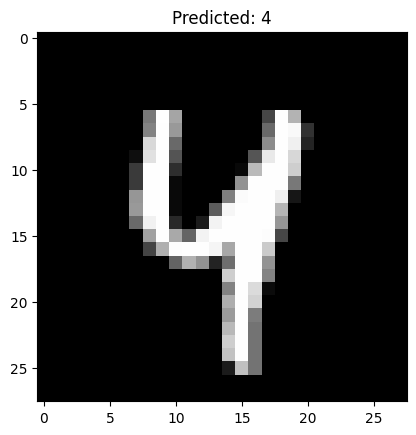

In [22]:
test(my_model, X_test_norm, Y_test_OH)

sample_idx = 42
prediction = np.argmax(my_model.forward(X_test_norm[:, sample_idx:sample_idx+1]))
print(f"Predicted: {prediction}, Actual: {Y_test[sample_idx]}")

plt.imshow(X_test[sample_idx], cmap='gray')
plt.title(f"Predicted: {prediction}")
plt.show()